# Bellabeat Case Study: Unlocking Smart Device Usage Trends
**Author:** Pascal Ndife  
**Tools:** Python (Pandas, NumPy, Matplotlib, Seaborn)  

---

## 1. Ask Phase
### Business Context & Task
Bellabeat is a high-tech wellness company designing smart health products specifically tailored for women. Urška Sršen (Cofounder & Chief Creative Officer) and Sando Mur have commissioned an analysis of non-Bellabeat smart fitness tracker data to identify consumer behavior patterns.

### Key Guiding Questions:
1. What are the macro trends in consumer smart device usage?
2. How do these daily activity and sleep habits apply to Bellabeat customers?
3. How can these insights drive the marketing strategy and product engagement for the **Bellabeat App**?

### Stakeholders:
* **Urška Sršen:** Cofounder and Chief Creative Officer
* **Sando Mur:** Mathematician and Cofounder
* **Bellabeat Marketing Analytics Team**

In [1]:
import os
import glob
import shutil
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Configure visual styling
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 10

In [3]:
# 1. Download Fitbit dataset from Kaggle
dataset_path = kagglehub.dataset_download("arashnic/fitbit")
print("Dataset downloaded to cache:", dataset_path)

100%|██████████| 43.3M/43.3M [00:24<00:00, 1.88MB/s]

Extracting files...


Dataset downloaded to cache: C:\Users\user\.cache\kagglehub\datasets\arashnic\fitbit\versions\2


In [4]:
# 2. Copy CSVs to local data/ directory
os.makedirs("data", exist_ok=True)
csv_files = glob.glob(os.path.join(dataset_path, "**", "*.csv"), recursive=True)
for file in csv_files:
    shutil.copy(file, "data/")

print(f"Successfully copied {len(csv_files)} CSV files into local ./data/ directory.")

Successfully copied 29 CSV files into local ./data/ directory.


## 2. Process Phase: Data Cleaning & Transformation
In this phase, we inspect the data integrity of the daily activity and sleep tables, handle null values, remove duplicates, and filter out non-wear days (zero-step records).

### Key Data Cleaning Steps:
1. **Activity Table:** Parse `ActivityDate` to standard datetime and filter out inactive records (`TotalSteps > 0`).
2. **Sleep Table:** Parse `SleepDay` to standard datetime and drop duplicate user-day logs.
3. **Feature Engineering:** Calculate `awake_in_bed_mins` (`TotalTimeInBed - TotalMinutesAsleep`) to track sleep latency/restlessness.
4. **Data Merge:** Perform a left join combining daily activity with sleep metrics on `Id` and `date`.

In [5]:
# 1. Load raw datasets
activity_df = pd.read_csv('data/dailyActivity_merged.csv')
sleep_df = pd.read_csv('data/sleepDay_merged.csv')

print(f"Raw Activity Rows: {len(activity_df)} | Unique Users: {activity_df['Id'].nunique()}")
print(f"Raw Sleep Rows: {len(sleep_df)} | Unique Users: {sleep_df['Id'].nunique()}")

Raw Activity Rows: 940 | Unique Users: 33
Raw Sleep Rows: 413 | Unique Users: 24


In [6]:
# 2. Clean Activity Table: Remove 0-step days and parse dates
activity_clean = activity_df[activity_df['TotalSteps'] > 0].copy()
activity_clean['date'] = pd.to_datetime(activity_clean['ActivityDate'], format='%m/%d/%Y')

In [7]:
# 3. Clean Sleep Table: Remove duplicates and parse dates
sleep_clean = sleep_df.drop_duplicates().copy()
sleep_clean['date'] = pd.to_datetime(sleep_clean['SleepDay'].str.split(' ').str[0], format='%m/%d/%Y')
sleep_clean['awake_in_bed_mins'] = sleep_clean['TotalTimeInBed'] - sleep_clean['TotalMinutesAsleep']

In [8]:
# 4. Merge datasets on Id and date
merged_df = pd.merge(
    activity_clean,
    sleep_clean[['Id', 'date', 'TotalSleepRecords', 'TotalMinutesAsleep', 'TotalTimeInBed', 'awake_in_bed_mins']],
    on=['Id', 'date'],
    how='left'
)

In [9]:
# 5. Extract day of week
merged_df['day_of_week'] = merged_df['date'].dt.day_name()

print(f"\nCleaned & Merged Rows: {len(merged_df)}")
print(f"Merged Records with valid Sleep Logs: {merged_df['TotalMinutesAsleep'].notnull().sum()}")


Cleaned & Merged Rows: 863
Merged Records with valid Sleep Logs: 410


In [10]:
# 1. Overall metric averages
metrics = ['TotalSteps', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories', 'TotalMinutesAsleep', 'awake_in_bed_mins']
means = merged_df[metrics].mean().round(1)

print("=== MACRO SUMMARY BENCHMARKS ===")
print(f"• Avg Daily Steps:         {means['TotalSteps']} steps")
print(f"• Avg Very Active Time:    {means['VeryActiveMinutes']} mins")
print(f"• Avg Sedentary Time:      {means['SedentaryMinutes']} mins ({round(means['SedentaryMinutes']/60, 1)} hours)")
print(f"• Avg Daily Calories:      {means['Calories']} kcal")
print(f"• Avg Sleep Duration:      {means['TotalMinutesAsleep']} mins ({round(means['TotalMinutesAsleep']/60, 1)} hours)")
print(f"• Avg Time Awake in Bed:   {means['awake_in_bed_mins']} mins")

=== MACRO SUMMARY BENCHMARKS ===
• Avg Daily Steps:         8319.4 steps
• Avg Very Active Time:    23.0 mins
• Avg Sedentary Time:      955.8 mins (15.9 hours)
• Avg Daily Calories:      2361.3 kcal
• Avg Sleep Duration:      419.2 mins (7.0 hours)
• Avg Time Awake in Bed:   39.3 mins


In [11]:
# 2. Segment Users by Daily Step Level
user_summary = merged_df.groupby('Id').agg(
    avg_steps=('TotalSteps', 'mean'),
    avg_sedentary=('SedentaryMinutes', 'mean'),
    avg_sleep=('TotalMinutesAsleep', 'mean'),
    avg_calories=('Calories', 'mean')
).reset_index()

def categorize_activity(steps):
    if steps < 5000:
        return 'Sedentary (<5k)'
    elif steps < 7500:
        return 'Low Active (5k-7.5k)'
    elif steps < 10000:
        return 'Fairly Active (7.5k-10k)'
    else:
        return 'Very Active (10k+)'

user_summary['user_category'] = user_summary['avg_steps'].apply(categorize_activity)
user_summary.to_csv('output/user_activity_segments.csv', index=False)

## 3. Share Phase: Data Visualizations & Trend Analysis
To communicate insights effectively to the executive team (Urška Sršen and Sando Mur), we visualize four key behavioral dimensions:
1. **Daily Step Habits across Days of the Week:** Comparing weekly movement vs. the CDC/WHO 10,000-step recommendation.
2. **User Segmentation Distribution:** Understanding what percentage of users fall into sedentary vs. active lifestyle categories.
3. **Caloric Burn vs. Daily Step Count:** Quantifying the statistical correlation between physical activity and energy expenditure.
4. **Sleep Duration Patterns:** Assessing whether users achieve healthy sleep consistency throughout the week.

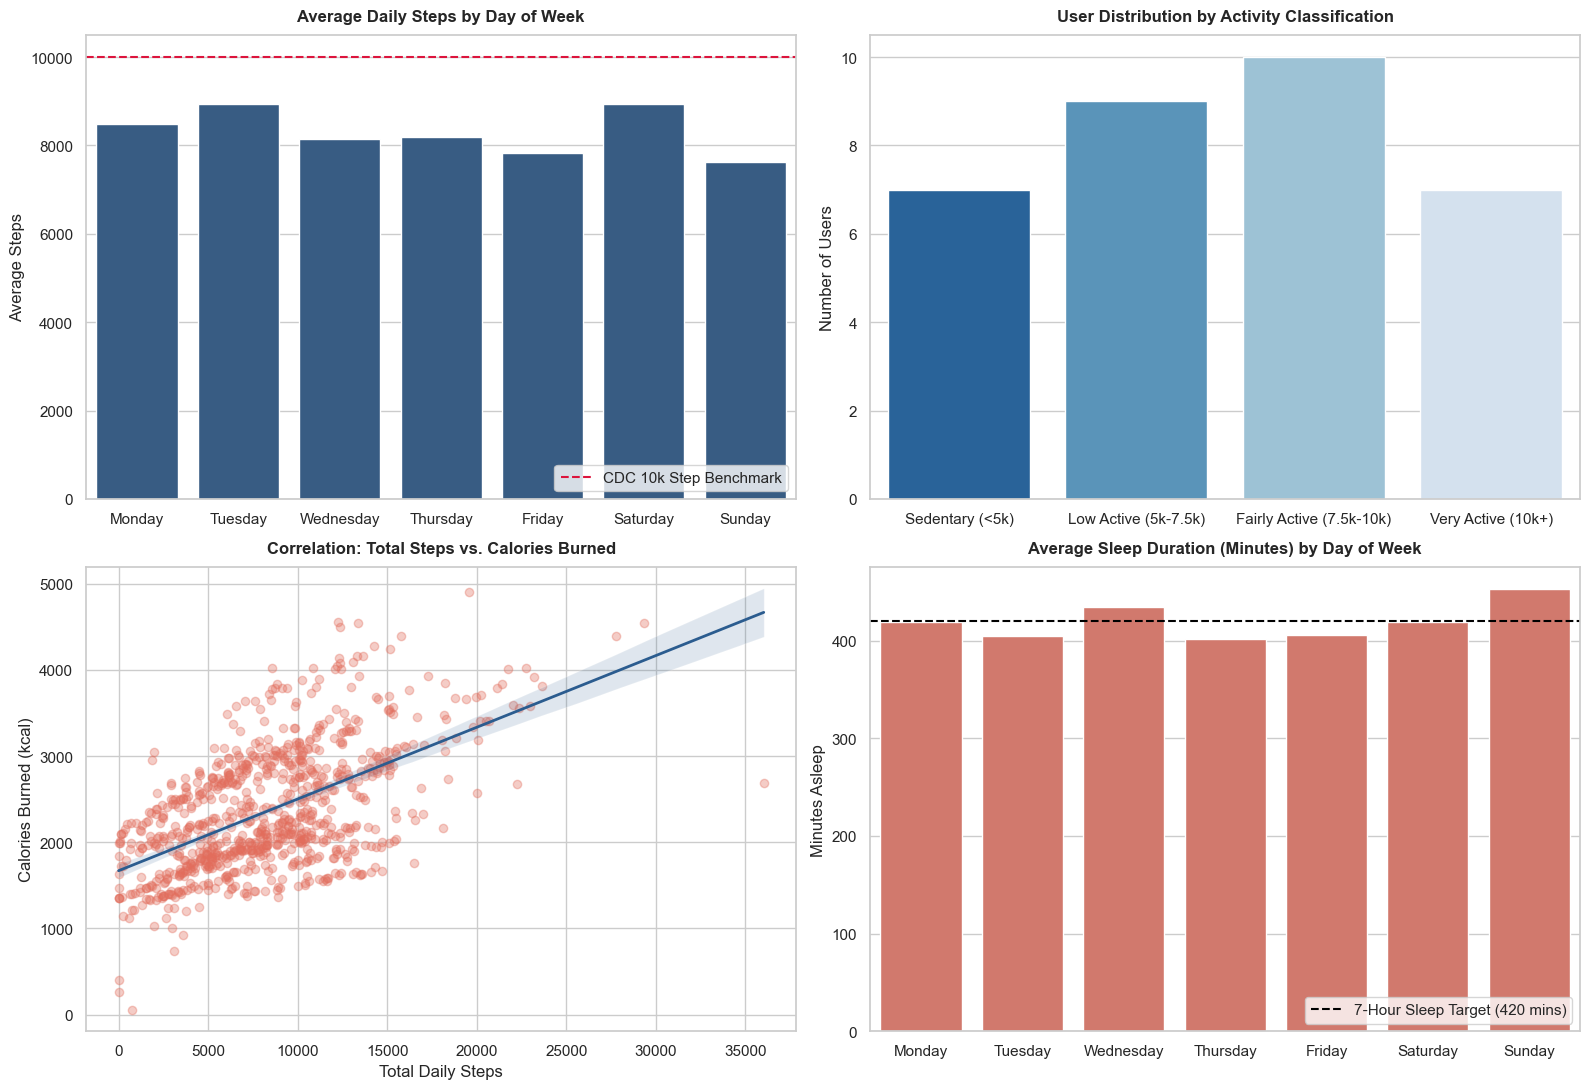

In [17]:
import os

# 1. Aggregate metrics by day of the week
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_agg = (
    merged_df.groupby('day_of_week')
    .agg(
        avg_steps=('TotalSteps', 'mean'),
        avg_sedentary=('SedentaryMinutes', 'mean'),
        avg_sleep=('TotalMinutesAsleep', 'mean'),
        avg_calories=('Calories', 'mean')
    )
    .reindex(days_order)
    .round(1)
    .reset_index()
)
weekday_agg.to_csv('output/weekday_summary.csv', index=False)

# 2. Initialize 2x2 Dashboard Figure
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Panel 1: Steps by Day of Week
sns.barplot(data=weekday_agg, x='day_of_week', y='avg_steps', color='#2b5c8f', ax=axes[0, 0])
axes[0, 0].axhline(10000, color='crimson', linestyle='--', linewidth=1.5, label='CDC 10k Step Benchmark')
axes[0, 0].set_title('Average Daily Steps by Day of Week', fontweight='bold', fontsize=12, pad=10)
axes[0, 0].set_ylabel('Average Steps')
axes[0, 0].set_xlabel('')
axes[0, 0].legend(loc='lower right')

# Panel 2: User Activity Classification
segment_order = ['Sedentary (<5k)', 'Low Active (5k-7.5k)', 'Fairly Active (7.5k-10k)', 'Very Active (10k+)']
segment_counts = (
    user_summary['user_category']
    .value_counts()
    .reindex(segment_order)
    .reset_index()
)
segment_counts.columns = ['user_category', 'count']

sns.barplot(
    data=segment_counts, 
    x='user_category', 
    y='count', 
    hue='user_category', 
    palette='Blues_r', 
    legend=False, 
    ax=axes[0, 1]
)
axes[0, 1].set_title('User Distribution by Activity Classification', fontweight='bold', fontsize=12, pad=10)
axes[0, 1].set_ylabel('Number of Users')
axes[0, 1].set_xlabel('')

# Panel 3: Steps vs Calories Regression
sns.regplot(
    data=merged_df, 
    x='TotalSteps', 
    y='Calories',
    scatter_kws={'alpha': 0.35, 'color': '#e26d5c'},
    line_kws={'color': '#2b5c8f', 'linewidth': 2},
    ax=axes[1, 0]
)
axes[1, 0].set_title('Correlation: Total Steps vs. Calories Burned', fontweight='bold', fontsize=12, pad=10)
axes[1, 0].set_xlabel('Total Daily Steps')
axes[1, 0].set_ylabel('Calories Burned (kcal)')

# Panel 4: Sleep Duration by Day of Week
sns.barplot(data=weekday_agg, x='day_of_week', y='avg_sleep', color='#e26d5c', ax=axes[1, 1])
axes[1, 1].axhline(420, color='black', linestyle='--', linewidth=1.5, label='7-Hour Sleep Target (420 mins)')
axes[1, 1].set_title('Average Sleep Duration (Minutes) by Day of Week', fontweight='bold', fontsize=12, pad=10)
axes[1, 1].set_ylabel('Minutes Asleep')
axes[1, 1].set_xlabel('')
axes[1, 1].legend(loc='lower right')

plt.tight_layout()
os.makedirs('visualizations', exist_ok=True)
plt.savefig('visualizations/bellabeat_executive_dashboard.png', dpi=300)
plt.show()

## 4. Act Phase: Strategic Recommendations for Bellabeat App & Membership

### 1. Daily Inactivity Alerts & Smart Movement Prompts
* **Insight:** Users average nearly 16 hours of sedentary time per day, and daily step averages consistently fall short of the 10k target.
* **Recommendation:** Implement automated in-app notifications and gentle vibrations on Bellabeat wearable hardware (Leaf/Time) after 60–90 minutes of continuous sedentary behavior, encouraging users to take a short walking break.

### 2. Evening Wind-Down & Sleep Quality Coaching
* **Insight:** Users take an average of ~40 minutes awake in bed before falling asleep, and weekday sleep regularly drops below the 7-hour standard.
* **Recommendation:** Introduce an in-app "Evening Wind-Down" routine starting 45 minutes before target bedtime, offering guided breathing, meditation, and hydration tracking reminders to improve sleep latency.

### 3. Tiered Challenges & Gamified Subscription Perks
* **Insight:** Over 75% of users fall into the low-to-fairly active range, yet activity directly correlates with caloric expenditure.
* **Recommendation:** Use the Bellabeat Membership subscription to launch community challenges (e.g., "Sunday Reset Stroll", "Consistent 8k Streak") with redeemable wellness perks to boost premium retention.

In [19]:
# 1. Create .gitignore
with open('.gitignore', 'w') as f:
    f.write("data/\n.ipynb_checkpoints/\n")

# 2. Create README.md
readme_text = """# Bellabeat Consumer Behavior Case Study

## Project Overview
An end-to-end data analytics case study investigating consumer health and activity habits using smart fitness tracker data following the Google Data Analytics methodology (Ask, Prepare, Process, Analyze, Share, Act).

## Key Findings
- **Sedentary Dominance:** Users average 15.9 hours of sedentary time daily, with steps consistently below 10k.
- **Activity vs. Caloric Burn:** Strong positive correlation between total steps and energy expenditure.
- **Sleep Restlessness:** Users average 7 hours of sleep but spend ~39 minutes awake in bed daily.

## Strategic Recommendations
1. **Sedentary Habit Disruption:** Smart inactivity nudges in the Bellabeat app after 60+ mins of sitting.
2. **Evening Wind-Down Guidance:** Bedtime mindfulness and sleep latency coaching in-app.
3. **Tiered Activity Challenges:** Bellabeat Membership challenges to activate low-to-mid step users.

## Project Structure
- `bellabeat_case_study.ipynb`: Complete analysis and visualization pipeline
- `output/`: Cleaned aggregate summaries
- `visualizations/`: Exported high-res dashboard figures
"""

with open('README.md', 'w') as f:
    f.write(readme_text)

print("Created .gitignore and README.md successfully.")

Created .gitignore and README.md successfully.
